┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; interpreting Array{Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136}} as Array{Any}
└ @ JLD2 C:\Users\kelem\.julia\packages\JLD2\hbsZG\src\datasets.jl:128
┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kelem\.julia\packages\JLD2\hbsZG\src\data\reconstructing_datatypes.jl:588
┌ Warning: type Main.#rho#136 does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kelem\.julia\packages\JLD2\hbsZG\src\data\reconstructing_datatypes.jl:472
┌ Warning: type SuiteSparseGraphBLAS.GBMatrix{Float64,Float64} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kelem\.julia\packages\JLD2\hbsZG\src\data\reconstructing_datatypes.jl:588
┌ Warning: type Base.RefValue{Ptr{SuiteSparseGraphBLAS.LibGraphBLAS.GB_Matrix_opaque}} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\k

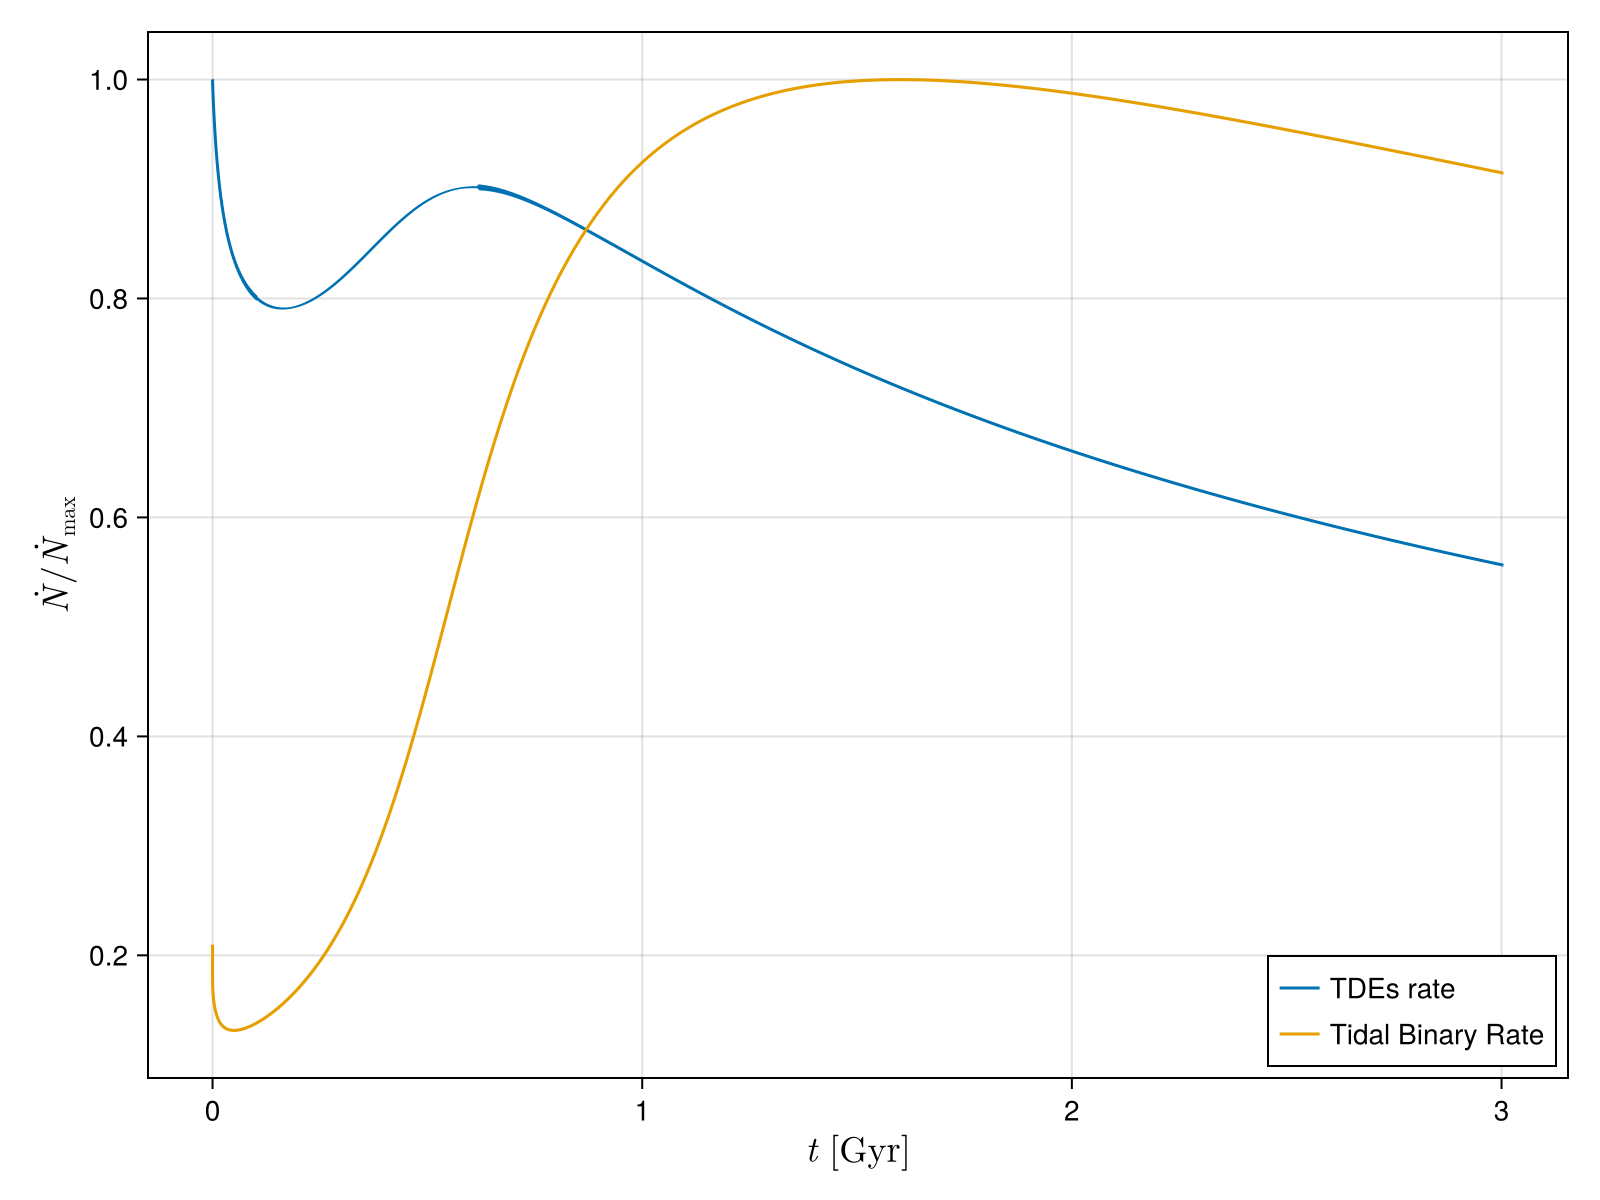

Insert the time t1 in Gyr:


stdin>  1


Insert the time t2 in Gyr:


stdin>  1.5


In [1]:
# ok haamos como si tuvieramos el simulador..

using JLD2, FileIO
using CairoMakie
using Printf
using Makie
using Dierckx
using Glob
using SpecialFunctions
using LinearAlgebra
using Distributions

final_output = load("C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/summary_2_4.0e6_4.8e-7_100x100.jld2")
params = final_output["params"]
aux = final_output["aux"]

time = final_output["t"]/params["Gyr"]
TDE_rate = final_output["captures"][1] * params["Gyr"] * 1e-9 #rates in 1/yr
TDE_binary = final_output["captures"][2] * params["Gyr"] * 1e-9 #rates in 1/yr

TDE_norm=TDE_rate/maximum(TDE_rate) #normalize rates
TDE_binary_norm=TDE_binary/maximum(TDE_binary) #normalize rates

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N} / \dot{N}_{\max}", xlabelsize= 18, ylabelsize= 18)

lines!(ax, time, TDE_norm, label="TDEs rate")
lines!(ax, time, TDE_binary_norm, label="Tidal Binary Rate")

axislegend(ax, position=:rb)

display(fig)

function trapz(x, y)
    sum( 0.5 * (y[1:end-1] .+ y[2:end]) .* diff(x) )
end

t=[]
folder = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7_old"
basename_prefix = "snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_"
files = glob(basename_prefix * "*", folder)

indices_snapshot = 1:length(files)-1 #explore how many snapshot there are

for i in indices_snapshot
    push!(t,time[i*40])
end

t_new=vcat(0,t)

println("Insert the time t1 in Gyr:")
t1 = parse(Float64, readline())
println("Insert the time t2 in Gyr:")
t2 = parse(Float64, readline())
max_ind = findall(x -> t1 <= x <= t2, t)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N}\ [1/yr] ", xlabelsize= 18, ylabelsize= 18)

lines!(ax, time, TDE_binary, label="TDEs binary")

vlines!(ax, [t1, t2], color=:red, linewidth=2, linestyle=:dash)

axislegend(ax, position=:rb)

save("Selected timespan $(params["M"])_0.1AU.pdf", fig)

E = params["E0"] * (exp.(aux["s_val"]) .- 1.0)

function besseli_leo(x,y)
    return besseli(0, x)./besseli(1, y)
end

q_t=[]
f_t=[]
dN_dEdt=[]

for i in max_ind
    snapshot_file = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7_old/snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    push!(dN_dEdt,snap["diff_rate"][2] * params["Gyr"])
    push!(q_t, snap["q"][2])
    push!(f_t, snap["f_e"][2])
end

dN_dEdt = Matrix(reduce(hcat, dN_dEdt)')
q_t = Matrix(reduce(hcat, q_t)')


N_E = length(E)
r_LC = final_output["params"]["rlc"][2]

N_rp = 100
r_p = range(0, r_LC; length=N_rp)
dx = step(r_p)

dNdrpdEdt = zeros(N_E, length(max_ind), N_rp)
dN_dEdt_2=dN_dEdt*0.0

for i in 1:N_E
    q = q_t[:,i]
    f = [ f_t[j][aux["Rlc_idx"][2][i], i] for j in 1:length(max_ind)]
    dNdrp_matrix = zeros(length(max_ind), length(r_p))
    for j in 1:length(max_ind) 
        dN_dEdt_2[:,i]=4*pi^2*aux["l2c"][i]*aux["Rlc"][2][i]*q.*(q.^2+q.^4).^-0.25 .* f
        arg = @. 2 * sqrt.(r_p ./ (q[j] * r_LC))
        norm = 2 / sqrt(q[j])
        if q[j] < 0.01
            dN_drp = zeros(length(r_p))
            x0 = r_LC
            ix = findall(abs.(r_p .- x0) .< dx/2)
            dN_drp[ix] .= 1 / dx
        elseif q[j] > 10
            dN_drp = fill(1/r_LC, length(r_p))
        else
            dN_drp = (1/(r_LC*sqrt(q[j]))) .* @.besseli_leo(arg, norm)
        end
        dNdrp_matrix[j, :] .= dN_drp
    end
    dNdrpdEdt[i, :, :] = dN_dEdt_2[:,i] .* dNdrp_matrix
    
end

dNdrpdE = [trapz(t_new[max_ind], dNdrpdEdt[i, :, j]) for i in 1:length(E), j in 1:length(r_p)]

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel=L"Specific\ energy\ in\ internal\ units", ylabel=L"r_{p}/r_{lc}", limits=(-200,10,nothing,nothing), title="Distribution of E and rₚ between t = $t1 and t = $t2 Gyr")
hm = CairoMakie.heatmap!(ax, -(E.-params["phis0"]), r_p/r_LC, dNdrpdE; colormap=:viridis, colorrange=(0, 0.5*maximum(dNdrpdE)))
Colorbar(fig[1,2], hm,  label = L"\frac{dN}{dE \, dr_p}")

dt = diff(t_new*1e9)
sub_TDE_binary=TDE_binary[1:40:end]
lambas=sub_TDE_binary[1:length(files)-1].*dt
lamba2=trapz(t_new[max_ind],sub_TDE_binary[max_ind])
e_for_plot=[]
e_for_plot2=[]
E_for_plot=[]
L_for_plot=[]
B_for_plot=[]
E_MBH=[]
a_for_plot=[]
q_for_plot=[]
EMRIs_time=[]

for p in 1:1
	realizations= 1:1
	TDE_final=[]
	for j in realizations
		Total_TDE=[]
		for i in lambas
			y=rand(Poisson(i))
			push!(Total_TDE,y)
		end
		push!(TDE_final,Total_TDE[max_ind])
	end

	snap1=[]
	time_snap=[]
		
	for i in 1:length(max_ind)
		if TDE_final[1][i]!=0
			for j in 1:TDE_final[1][i]
				push!(snap1, max_ind[i])
				push!(time_snap, t_new[max_ind[i]])
			end
		end
	end

    push!(EMRIs_time, time_snap)
    
	using Random, Interpolations

	GMsun_km = 1.3271244e11       # km^3/s^2,
	AU_in_km = 1.495978707e8      # km to AU
	N_events=sum(TDE_final[1])

	accepted_energies_final=[]
	for j in realizations
		accepted_energies = []
		for i in 1:length(max_ind)
			itp = interpolate((E,), dN_dEdt_2[i,:], Gridded(Linear()))
			
			p_max = maximum(dN_dEdt_2[i,:])
		
			N_TDE = TDE_final[j][i]
		
			E_min = minimum(E)
			E_max = maximum(E)
		
			Ei = Float64[]
			
			while length(Ei) < N_TDE
				E_trial = rand() * (E_max - E_min) + E_min
				y = rand() * p_max
				if y < itp(E_trial)
					push!(Ei, E_trial)
				end
			end
		
			push!(accepted_energies, Ei)
		end
		push!(accepted_energies_final, accepted_energies)
	end

	acepted_rp_total=[]
	acepted_B_total=[]
	q_out=[]
	
	for k in realizations
		accepted_rp = []
		accepted_B = []
		for i in max_ind
			snapshot_file = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7_old/snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_$(@sprintf("%03d", i)).jld2"
			snap = load(snapshot_file)
			energies = accepted_energies_final[k][i-minimum(max_ind)+1]
			q_E = snap["q"][2]
			itp_qE = interpolate((E,), q_E, Gridded(Linear()))
			rp= Float64[]
			B= Float64[]
			for j in energies
				q=itp_qE(j)
				push!(q_out, q)
				arg = @. 2 * sqrt.(r_p ./ (q * r_LC))
				norm = 2 / sqrt(q)
				if q < 0.01
					push!(rp,r_LC)
					push!(B, 1)
				elseif q > 10
					push!(rp, rand() * r_LC)
					push!(B, r_LC / (rand() * r_LC))
				else
					dN_drp = (1/(r_LC*sqrt(q))) .* @.besseli_leo(arg, norm)
					while true  
						itp_rp = interpolate((collect(r_p),), dN_drp, Gridded(Linear()))
						rp_trial = rand() * r_LC
						p_max = maximum(dN_drp)
						y = rand() * p_max          
						if y < itp_rp(rp_trial)
							push!(rp, rp_trial)
							push!(B, r_LC/rp_trial)
							break
						end
					end
				end
			end
			push!(accepted_rp,rp)
			push!(accepted_B,B)
		end
		push!(acepted_rp_total, accepted_rp)
		push!(acepted_B_total, accepted_B)
	end

	Specific_energies=vcat(vcat(accepted_energies_final...)...)*(params["sigma"]*(params["v_u"])/1000)^2
	push!(E_for_plot, Specific_energies)
	Specific_energies_2 = -(Specific_energies.-params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2)
    push!(E_MBH, Specific_energies_2)
	Beta=vcat(vcat(acepted_B_total...)...)
	push!(B_for_plot,Beta)
    push!(q_for_plot, q_out)
	# @infiltrate
	a_km = - (GMsun_km * params["M"]) / (2 * Specific_energies_2)

	a_au = a_km / AU_in_km

	push!(a_for_plot, a_au)
    
	L_out=[]
	rLC_km = r_LC * params["r_u"] / 1000.0
	for i in 1:length(Beta)
		L= (2 * (rLC_km/Beta[i])^2 * ( GMsun_km * params["M"] / (rLC_km/Beta[i]) - Specific_energies_2[i]))^(1/2)
		push!(L_out, L)
	end
	
	push!(L_for_plot, L_out)

	e=[]
	# @infiltrate
	
	for i in 1:length(a_km)
		# if a_au[i]<0
		# 	e_i=1+(r_LC/Beta[i])/(abs(a_au[i]))
		# 	push!(e,e_i)
		# else
			e_i=1-rLC_km/Beta[i]/a_km[i]
			push!(e,e_i)
		# end
	end
	# e2= sqrt.(1.0 .+ 2*Specific_energies_2 .* L_out.^2 / (GMsun_km * params["M"])^2)
	e2= Specific_energies_2 .* L_out.^2 / (GMsun_km * params["M"])^2
	
	push!(e_for_plot, e)
	push!(e_for_plot2, e2)
	
	filename = "$(params["M"])_0.1AU_$(p)_$(length(aux["R_val"]))_" * @sprintf("t1_%.3f_t2_%.3f_data_summary.txt", t1, t2)

	open(filename, "w") do io	
		@printf(io, "Number of events between t = %.4f and %.4f Gyr: %d\n", t1, t2, N_events)
		@printf(io, "Method used: Explore snapshot by snapshot \n")
		@printf(io, "Mass of the MBH: %.2e solar masses\n\n", params["M"])
		@printf(io, "The stellar potential is: %.2e [km/s]^2 \n\n", params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2 )
		
		@printf(io, "%-25s %-15s %-15s %-15s %-10s %-15s %-15s\n", "Total energy [(km/s)^2]", "Specific energy MBH", "Beta", "L [(km^2/s)]", "q", "Snapshot", "Snapshot time [Gyr]")
		@printf(io, "%s\n", "-"^115)

		for (e_val, e_MBH, b, R, q, snap_val, t_snap) in zip(Specific_energies, Specific_energies_2, Beta, L_out, q_out, snap1, time_snap)
			@printf(io, "%-25.5e %-15.5e %-15.5e %-15.5e %-10.5f %-15d %-15.5f\n", e_val, e_MBH, b, R, q, snap_val, t_snap)
		end
	end
end
		
B_for_plot=reduce(vcat, B_for_plot)
E_MBH=reduce(vcat, E_MBH)

fig = Figure()
e_for_plot=reduce(vcat, e_for_plot)
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"1-e", title="Just a prove",   xscale = log10)
CairoMakie.scatter!(ax, B_for_plot, -e_for_plot.+1, markersize=5, color=:red)
save("e_dist_prove.pdf", fig)

fig = Figure()
ome2_for_plot=reduce(vcat, e_for_plot2)
ome_for_plot = 1.0 .- sqrt.(ome2_for_plot .+ 1.0)
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"1-e", title="Just a prove",   xscale = log10)
CairoMakie.scatter!(ax, B_for_plot, ome_for_plot, markersize=5, color=:red)
save("e_new_dist_prove.pdf", fig)

fig = Figure()
E_for_plot = reduce(vcat, E_for_plot) 
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"Specific total energy [Km/s]^2", title="Just a prove",   xscale = log10, limits = (1, 100, nothing, nothing))
CairoMakie.scatter!(ax, B_for_plot, E_for_plot, markersize=5, color=:red)
CairoMakie.hlines!(params["phis0"]*(params["sigma"]*(params["v_u"])/1000)^2, linestyle=:dash)
save("E_dist.pdf", fig)

fig = Figure()
L_for_plot = reduce(vcat, L_for_plot) 
ax = Axis(fig[1,1], xlabel=L"Beta", ylabel=L"Specific angular momentum [km^2/s]", title="Just a prove",   xscale = log10, yscale=log10, limits = (1, 100, nothing, nothing))
CairoMakie.scatter!(ax, B_for_plot, L_for_plot, markersize=5, color=:red)
save("L_dist.pdf", fig)

a_for_plot=v = collect(transpose(a_for_plot)) 
fig = Figure()
a_for_plot = reduce(vcat, a_for_plot) 
ax = Axis(fig[1,1], xlabel=L"a (AU)", ylabel=L"e", title="Just a prove")
CairoMakie.scatter!(ax, a_for_plot, sqrt.(ome2_for_plot .+ 1.0), markersize=5, color=:red)
save("e vs a.pdf", fig)

EMRIs_time = reduce(vcat, EMRIs_time)
q_for_plot = reduce(vcat, q_for_plot) 
Beta=B_for_plot
a=a_for_plot;

In [3]:
#e vs Beta

fig = Figure()
ome2_for_plot=reduce(vcat, e_for_plot2)
ome_for_plot = 1.0 .- sqrt.(ome2_for_plot .+ 1.0)
ax = Axis(fig[1,1], xlabel=L"\beta", ylabel=L"1-e", xscale = log10, limits = (nothing, nothing, -0.0003, 0.001), xlabelsize = 18, ylabelsize = 18)
sc = CairoMakie.scatter!(
    ax, 
    B_for_plot, 
    ome_for_plot,
    markersize = 5,
    color = log10.(Float64.(q_for_plot)),  
    colormap = :viridis, 
    colorrange = (-6, 2) 
)

Colorbar(fig[1,2], sc, label = L"log(q)", labelsize = 18)

save("e_new_dist_prove.pdf", fig)


CairoMakie.Screen{PDF}


In [4]:
#e vs beta as a function of the loss cone regime

fig = Figure()

ax = Axis(fig[1,1],
    xlabel = L"\beta",
    ylabel = L"1-e",
    xscale = log10,
    limits = (nothing, nothing, -0.0003, 0.001), xlabelsize = 18, ylabelsize = 18
)

mask_ELC = q_for_plot .< 0.01    
mask_noELC = .!mask_ELC       

sc1 = CairoMakie.scatter!(
    ax,
    B_for_plot[mask_ELC],
    ome_for_plot[mask_ELC],
    markersize = 5,
    color = :blue,
    label = "ELC (q < 0.01)"
)

sc2 = CairoMakie.scatter!(
    ax,
    B_for_plot[mask_noELC],
    ome_for_plot[mask_noELC],
    markersize = 5,
    color = :red,
    label = "No ELC (q ≥ 0.01)"
)

Legend(fig[1,2], ax)

save("e_new_LCR.pdf", fig)

CairoMakie.Screen{PDF}


In [5]:
#Distribution of beta and energy for disrupted sBHBs

fig = Figure()
ax = Axis(fig[1,1],
    xlabel = L"\beta",
    ylabel = L"Specific\ Energy\ [\mathrm{km^2\ s^{-2}}]",
    xscale = log10, xlabelsize = 18, ylabelsize = 18, limits = (nothing, nothing, -1.5e6, 1e5)
)
sc = CairoMakie.scatter!(
    ax,  
    Beta,
    E_MBH,
    markersize = 5,
    color = log10.(Float64.(q_for_plot)),
    colormap = :viridis, 
    colorrange = (-6, 2) 
)

Colorbar(fig[1,2], sc, label = L"log(q)", labelsize = 18)

save("Heat_map_better.pdf", fig)


CairoMakie.Screen{PDF}


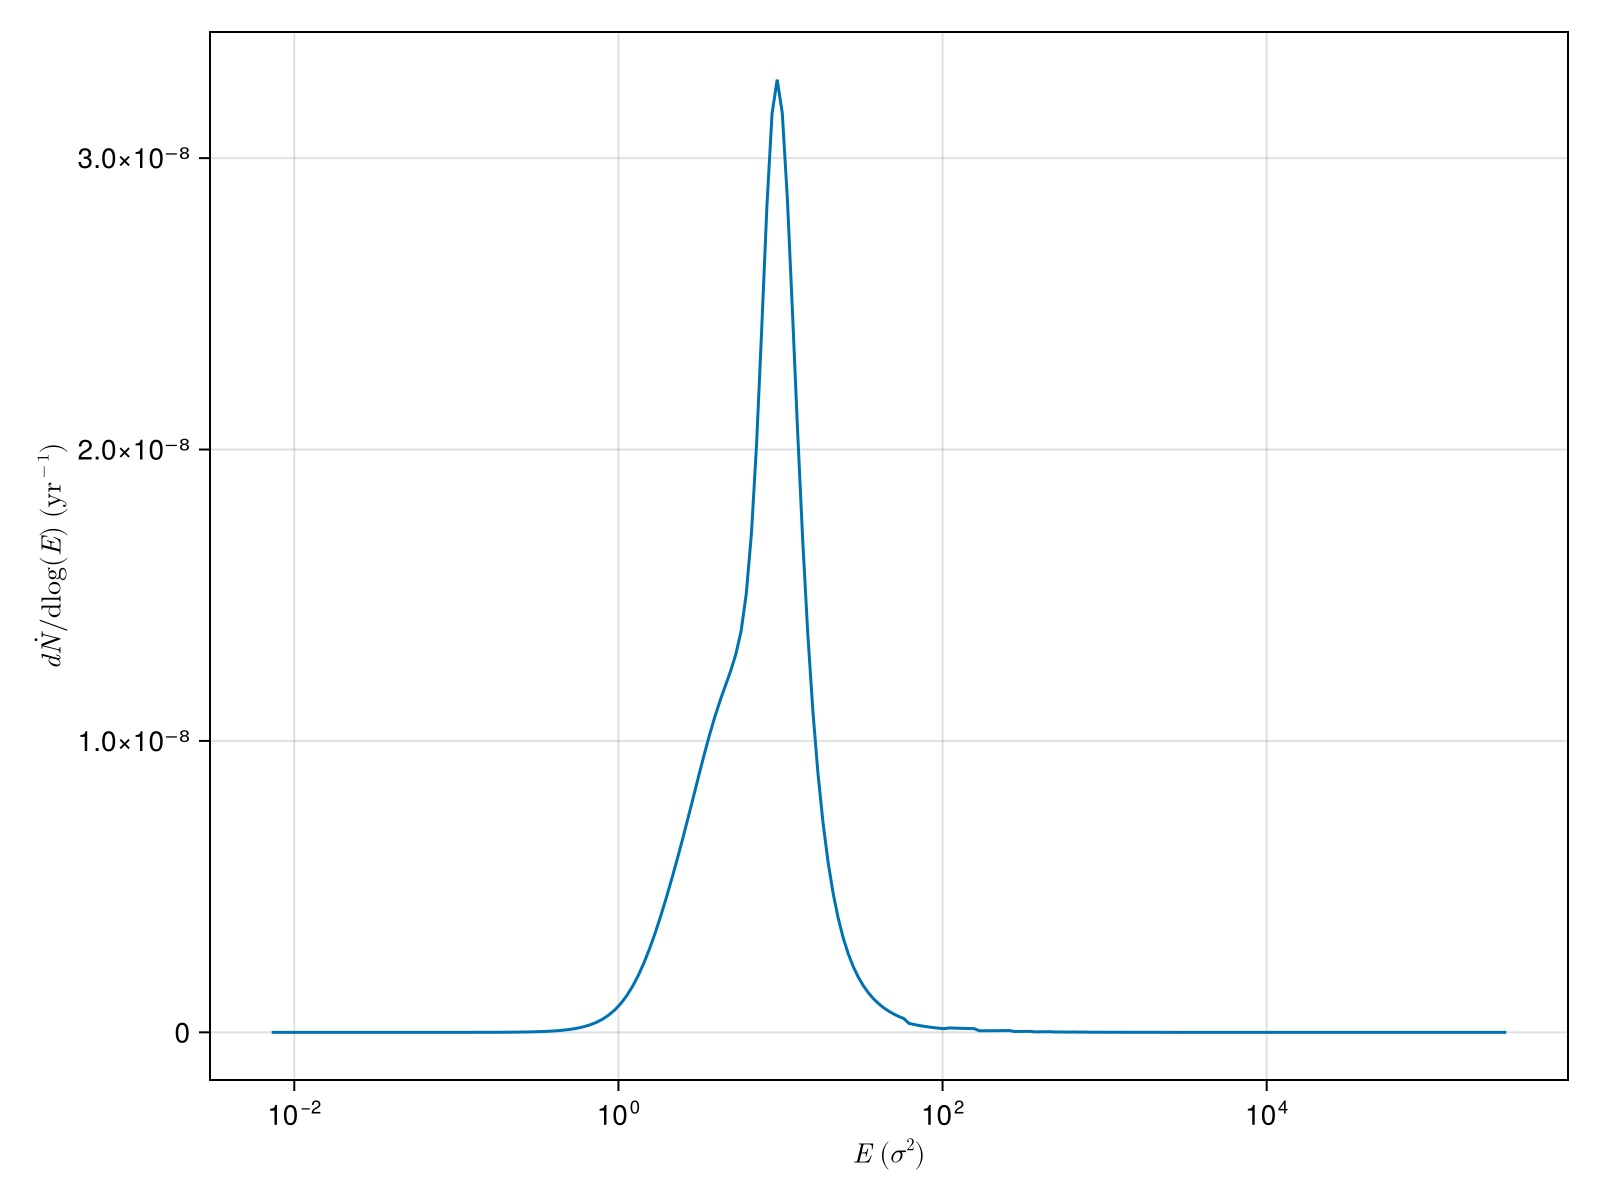

CairoMakie.Screen{IMAGE}


In [25]:
#just plot a random diff rate.

#ploteomos 

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xscale=log10,     xlabel = L"E\;(\sigma^2)",
    ylabel = L"d\dot{N} / \mathrm{d}\log(E)\;(\mathrm{yr}^{-1})")

lines!(ax, E, E.*dN_dEdt[100,:]* 1e-9, label="Diff rate at 2.3 Gyr")

display(fig)

In [105]:
#trying to get the line t_gw = t_rlx

t_scatter_R = (aux["R_val"].^2 ./ (aux["DRR"] .* params["Gyr"])) .* aux["C"]

t_scatter_R[isnan.(t_scatter_R)] .= 0 
t_scatter_R;

100×100 Matrix{Float64}:
   416.212        219.096      …    0.0       0.0       0.0       0.0
  2015.25         646.473           0.0       0.0       0.0       0.0
  5155.77        1248.57            0.0       0.0       0.0       0.0
 10392.1         2035.05            0.0       0.0       0.0       0.0
 18074.3         3056.6             0.0       0.0       0.0       0.0
 28724.6         4329.39       …    0.0       0.0       0.0       0.0
 42491.2         5837.2             0.0       0.0       0.0       0.0
 59847.7         7695.15            0.0       0.0       0.0       0.0
 82476.6         9853.0             0.0       0.0       0.0       0.0
     1.07647e5  12369.5             0.0       0.0       0.0       0.0
     1.40211e5  15240.8        …    0.0       0.0       0.0       0.0
     1.74606e5  18648.5             0.0       0.0       0.0       0.0
     2.16985e5  22215.0             0.0       0.0       0.0       0.0
     ⋮                         ⋱                               
 

In [33]:
# or using directly, whit this plot directly and leave it
snapshot_file = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_$(params["M"])_4.8e-7_old/snap_grid_$(length(aux["R_val"]))x$(length(aux["s_val"]))_164.jld2"
snap = load(snapshot_file)
q=snap["q"][2]

P = aux["C"][end,:] ./ (4*pi^2*aux["l2c"])
D = q .* aux["Rlc"][2] ./ P

e = 1 .- ((85/6/sqrt(2) * params["G"]^3/params["c"]^5 * params["M"]^2)^(2/5) ./ D.^(2/5) ./ aux["rc"].^(8/5) ) * 10^(2/5)

100-element Vector{Float64}:
     0.9999999997843562
     0.9999999989122826
     0.9999999974868434
     0.9999999955023854
     0.9999999930199642
     0.9999999900782496
     0.9999999868233986
     0.9999999832863666
     0.999999979561648
     0.9999999755930556
     0.9999999713888481
     0.9999999668350004
     0.9999999618734845
     ⋮
  -100.93194288803392
  -134.49367366602962
  -179.12198616851987
  -238.47447231941916
  -317.41904461652024
  -422.4325421376693
  -562.1290815804948
  -747.9620164930438
  -995.1557478847374
 -1323.946423994847
 -1761.2391541901652
 -2342.824987335091

In [177]:
P_orb = P_orb / params["Gyr"]

t_scatter_R=(P_orb./q).*(aux["R_val"]./aux["Rlc"][2]');

100×100 Matrix{Float64}:
  1916.78          583.531       …     3.19692e-6      3.19692e-6
  9941.88         3026.63              1.65816e-5      1.65816e-5
 23638.4          7196.28              3.94254e-5      3.94254e-5
 41901.9         12756.3               6.98863e-5      6.98863e-5
 61437.6         18703.6               0.000102469     0.000102469
 79712.2         24267.0         …     0.000132948     0.000132948
 92935.5         28292.6               0.000155003     0.000155003
     1.00874e5   30709.2               0.000168243     0.000168243
     1.03042e5   31369.4               0.00017186      0.00017186
     1.01417e5   30874.5               0.000169148     0.000169148
 96811.6         29472.6         …     0.000161468     0.000161468
 90817.8         27647.9               0.000151471     0.000151471
 83973.5         25564.3               0.000140056     0.000140056
     ⋮                           ⋱                  
     1.19988e11      3.65283e10      200.123         200

In [23]:
#ok tGW 
#c=3.066e5 #pc Gyr-1
#G=4.49e-12 #pc3 solar -1 Gyr-1
G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 299792458.0          # m/s
Msun = 1.989e30          # kg
pc = 3.085677581e16      # m
seconds_in_Gyr = 3.1536e16  # s
M = 4.3e6 * Msun         
m = 10 * Msun
a = 10 .^ range(-5.4, 0; length=1000) #pc
R = range(0.005, 0.995; length=1000)
R_col = reshape(R, :, 1)
a_row = reshape(a, 1, :)
a_new = a_row .* pc       

function tGW(a, R)
    return ((15/304) * (c^5 .* a.^4 )./ (G^3 * M * m * (M + m)) .* ((1 .- sqrt.(1 .- R)) .*  (R .^(5/2)))./(sqrt.(1 .- R)) .* (1+ (121/304).*(-R.+1)).^(-1))
end                                                                                               

tGW_matrix = (tGW.(a_new, R_col)) ./ seconds_in_Gyr ;

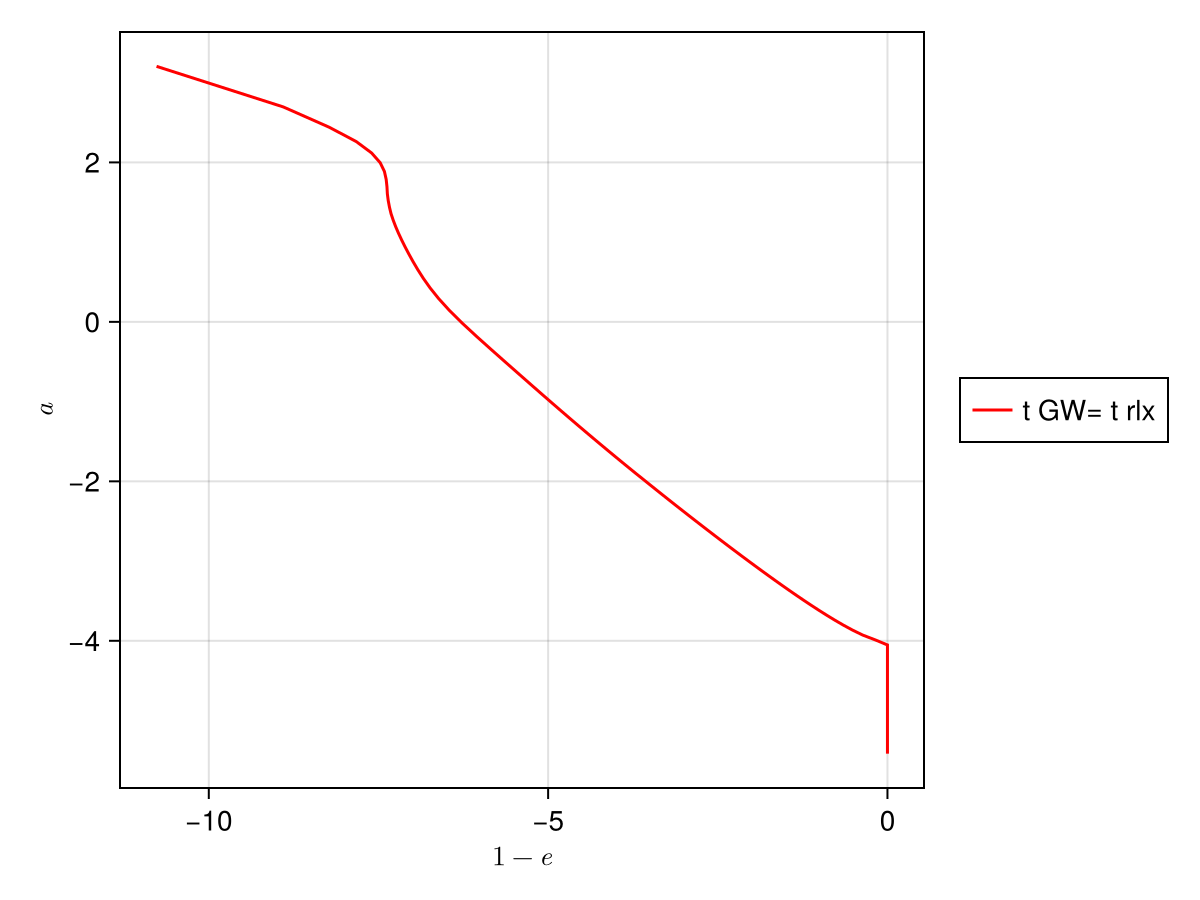

CairoMakie.Screen{IMAGE}


In [108]:
R_eq=[]
for a in eachindex(aux["rc"])
    validindex=aux["R_val"].>aux["Rlc"][2][a]
    if any(validindex)
        itp_rlx=linear_interpolation(log10.(aux["R_val"][validindex]), log10.(t_scatter_R[validindex,a]), extrapolation_bc=Line())
        trlx(R)=exp10(itp_rlx(log10(R)))
#trlx = trlc^LC * R/Rlc, can be writting
#tGW = tGW^LC * (R/RLC)^3.5 scalings for very eccentric orbits 
# (R/RLC) = (trlx^LC/tGW^LC)^(2/5)
# R_tgwtrlx = RLC * (trlx^LC/tGW^LC)^(2/5) #valuo of R when both are equal , inside the loop.
        trlx_lc=trlx(aux["Rlc"][2][a])
        tGW_lc=tGW(aux["rc"][a]*pc, aux["Rlc"][2][a])/seconds_in_Gyr
        push!(R_eq, min((aux["Rlc"][2][a]*(trlx_lc/tGW_lc)^(2/5)),1))
    else 
        push!(R_eq, 1)
    end
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"1-e", ylabel=L"a")
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:red, label="t GW= t rlx")
Legend(fig[1, 2], ax)
display(fig)
#we get t_gw = t_rlx

In [35]:
#getting the depostid BHs propiertes

using CSV, DataFrames, StatsBase, Distributions
using CategoricalArrays

df = CSV.read("fractions_data_E0.csv", DataFrame)
n_bins = 200
beta_vals = df.beta_0
edges = range(minimum(beta_vals), stop=maximum(beta_vals), length=n_bins+1)
bin_centers = [0.5*(edges[i] + edges[i+1]) for i in 1:n_bins]

beta_filt = filter(x -> 1 <= x <= maximum(beta_vals), Beta);

In [37]:
#lets do filter by prob

beta_ref = df[:, 1] 
p_ref    = df[:, 2]  

beta_final = [
    β for β in beta_filt
    if rand() ≤ p_ref[argmin(abs.(beta_ref .- β))]
];

In [38]:
bin_cats_filt = cut(beta_final, edges; extend=true)
bin_indices_filt = bin_cats_filt.refs
counts_per_bin = countmap(bin_indices_filt) 
bin_counts = [get(counts_per_bin, i, 0) for i in 1:n_bins] ;

In [41]:
using KernelDensity

df_2 = CSV.read("M4e6_E0.csv", DataFrame)

sampled_a = Float64[]
sampled_e = Float64[]

for i in 1:n_bins
    beta_min = edges[i]
    beta_max = edges[i+1]
    n_events = bin_counts[i]

    bin_data = filter(row -> beta_min ≤ row.beta_0 < beta_max, df_2)

    if n_events > 0
        x = bin_data.a_cap
        y = bin_data.e_cap
        points = hcat(x, y)
        
        # KDE 2D
        kde_0 = kde(points)

        for j in 1:n_events
            accepted = false
            while !accepted
                a_try = rand(Uniform(minimum(x), maximum(x)))
                e_try = rand(Uniform(minimum(y), maximum(y)))
                p = pdf(kde_0, a_try, e_try)

                p_max = maximum(kde_0.density)
                if rand() < p / p_max
                    push!(sampled_a, a_try)
                    push!(sampled_e, e_try)
                    accepted = true
                end
            end
        end
    end
end

@show length(sampled_a)
@show length(sampled_e)

length(sampled_a) = 406
length(sampled_e) = 406


406

In [42]:
#the loss cone for the remains BH

x_vals = range(-4, 0, length=200)
const_val = log10((8 * G * M / c^2)*3.24e-17) 
y_vals = .-x_vals .+ const_val;

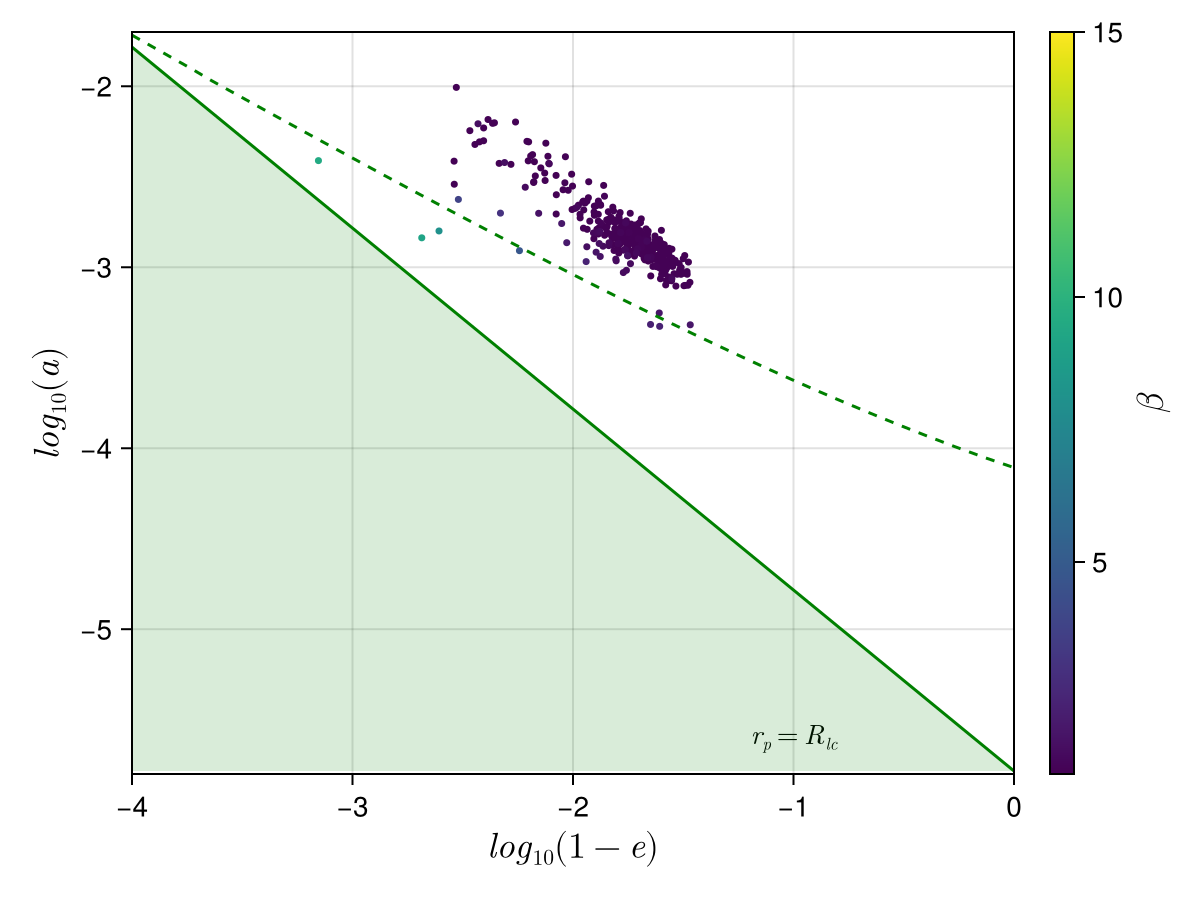

CairoMakie.Screen{PDF}


In [43]:
colors_labels = Float64[]
for (cant, val) in zip(bin_counts, bin_centers)
    append!(colors_labels, fill(val, cant))
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)", xlabelsize = 18, ylabelsize = 18)
sc=CairoMakie.scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(1 .-e), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(1 .-e)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\beta", labelsize = 18)
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)
display(fig)

save("Remaining BHs.pdf", fig)
#evolving with rp = cts paralel to the LC , simulation of peter eq.
#do it with a bulk around -2

In [44]:
# just curoisity, how many points are inside , how many are outside
using Logging

global_logger(ConsoleLogger(stderr, Logging.Error))

x_line = log10.(1 .-e)
y_line = log10.(aux["rc"])

x_line = collect(x_line)
y_line = collect(y_line)

x_pts = log10.(-sampled_e .+ 1)
y_pts = log10.(sampled_a)

itp = LinearInterpolation(x_line, y_line, extrapolation_bc=Flat())

y_on_line = itp.(x_pts)

n_inside = sum(y_pts .<= y_on_line)   # puntos por debajo de la línea
n_outside = sum(y_pts .> y_on_line)   # puntos por encima de la línea

println("Puntos dentro de la línea: $n_inside")
println("Puntos fuera de la línea: $n_outside")

Puntos dentro de la línea: 6
Puntos fuera de la línea: 400


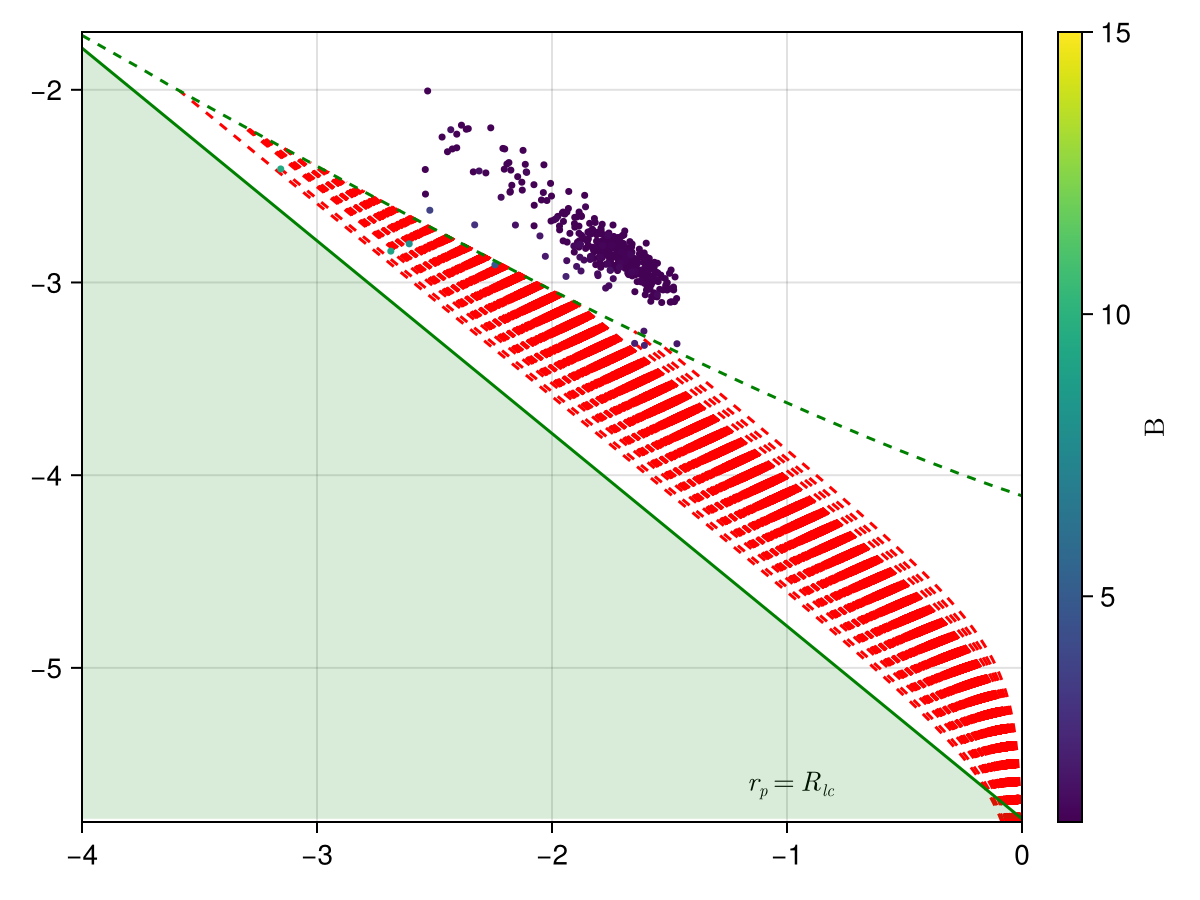

CairoMakie.Screen{IMAGE}


In [49]:
#time to evolving..until lisa band

inside_mask = y_pts .<= y_on_line
outside_mask = .!inside_mask

# Puntos dentro
x_inside = x_pts[inside_mask]
y_inside = y_pts[inside_mask]

# Puntos fuera proyectados horizontalmente
x_outside_proj = similar(x_pts[outside_mask])
y_outside_proj = y_pts[outside_mask]  # a fijo

sorted_idx = sortperm(y_line)
y_line_sorted = y_line[sorted_idx]
x_line_sorted = x_line[sorted_idx]

for (i, a_val) in enumerate(y_outside_proj)
    # Buscamos e tal que el punto cruce la línea (manteniendo a fijo)
    # Simplemente buscamos el x de la línea correspondiente al y fijo
    # Invertimos la interpolación (aproximación)
    itp_inv = LinearInterpolation(y_line_sorted, x_line_sorted, extrapolation_bc=Flat())
    x_outside_proj[i] = itp_inv(a_val)
end

# --- 2. Preparar listas finales de puntos iniciales ---
x_evol_init = vcat(x_inside, x_outside_proj)
y_evol_init = vcat(y_inside, y_outside_proj)

# Convertir de log10 a valores reales para Peters
e_init = 1 .- 10 .^ x_evol_init
a_init = 10 .^ y_evol_init

# --- 3. Evolución usando Peters ---
function a_peters(e, c0)
    return c0 * (e.^(12/19)) ./ (1 .- e.^2) .* (1 .+ 121/304 .* e.^2).^(870/2299)
end

const C = 2.88e-8
M = 4e6
resultado = C * (M / 1)^(1/3) #esta es la ecuacion de la xd

a_target = 3.24e-6
e_at_a_target = Float64[]
log_a_target = log10.(a_target)

fig = Figure()
ax = Axis(fig[1,1])

function obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    log_a_vals = log10.(a_vals)
    if minimum(log_a_vals) > log_a_target
        return missing 
    end
    interp_e = linear_interpolation(log_a_vals, e_vals, extrapolation_bc=Line())
    return interp_e(log_a_target)
end

first=true
for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target, e_at_log_a_p)

    # Graficar evolución
    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    if first
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

sc=CairoMakie.scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(1 .-e), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
#text!(ax, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

display(fig)

In [51]:
using Plots
using StatsBase   # para fit(Histogram, ...)

# Calcular histograma sin graficar
h = fit(Histogram, e_at_a_target; nbins=20)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

savefig("hist_eccentricity_lisa.pdf")

0.13118226600985222

"C:\\Users\\kelem\\hist_eccentricity_lisa.pdf"

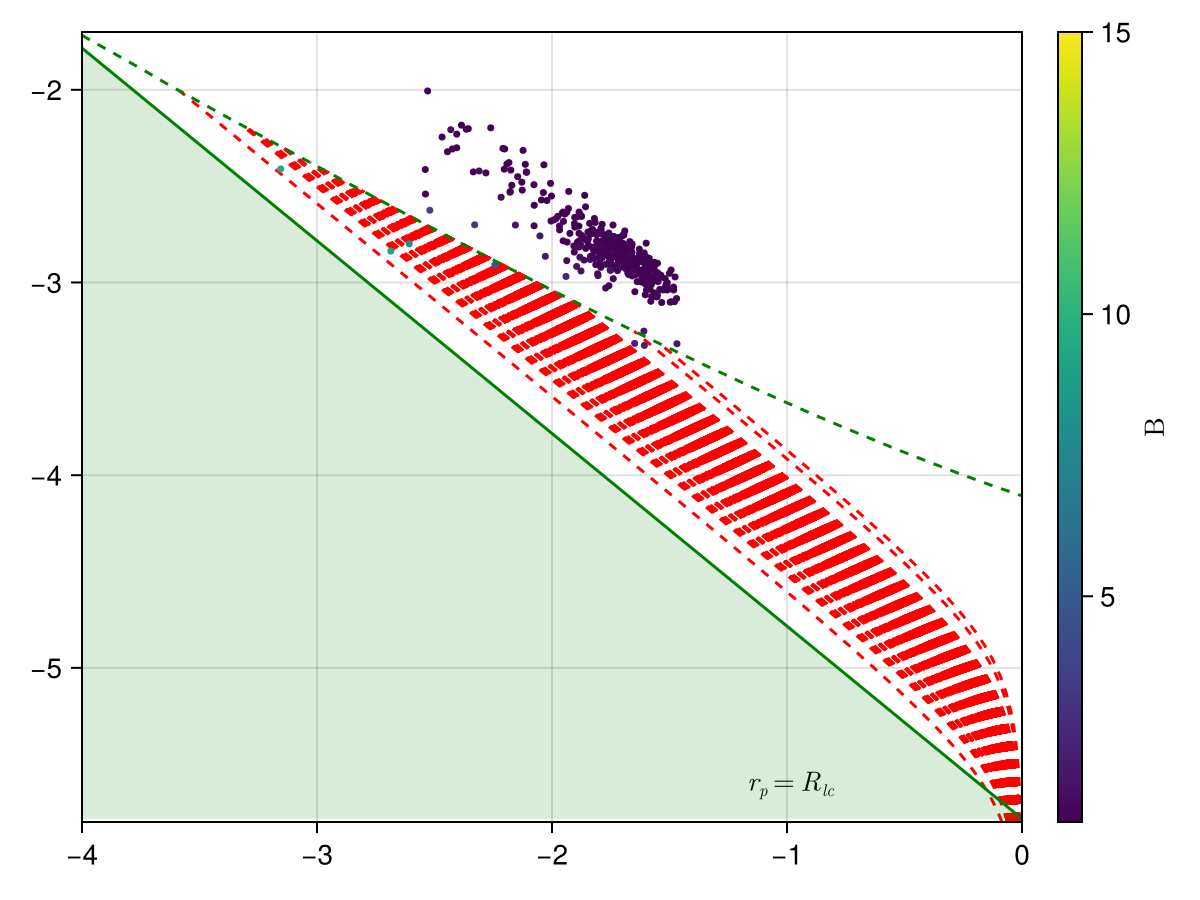

CairoMakie.Screen{IMAGE}


In [53]:
#ahora solo los putnos que estn fuera xd

# solo out:
e_init_out = 1 .- 10 .^ x_outside_proj
a_init_out = 10 .^ y_outside_proj

e_at_a_target_out = Float64[]

fig = Figure()
ax_2 = Axis(fig[1,1])

first=true
for (e0, a0) in zip(e_init_out, a_init_out)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_out, e_at_log_a_p)

    # Graficar evolución
    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    if first
        lines!(ax_2, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution")
        first = false
    else
        lines!(ax_2, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

sc=CairoMakie.scatter!(ax_2, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax_2, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax_2, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax_2, log10.(1 .-e), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
#text!(ax_2, [maximum(log10.(-sqrt.(-R_eq.+1).+1)) - 0.8], [log10.(aux["rc"])[end] + 1.5], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax_2,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

display(fig)

In [54]:
# Calcular histograma sin graficar
h = fit(Histogram, e_at_a_target_out; nbins=20)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed = vcat(Base.first(edges), x, Base.last(edges))
y_closed = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed, y_closed;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

savefig("hist_eccentricity_lisa_onlyout.pdf")

0.1301

"C:\\Users\\kelem\\hist_eccentricity_lisa_onlyout.pdf"

In [55]:
# hasta QPE 2 band

a_target = 5.15e-6
e_at_a_target_2 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_2, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_2; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed1 = vcat(Base.first(edges), x, Base.last(edges))
y_closed1 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed1, y_closed1;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.24401477832512314

In [56]:
# ahora con eRO-QPE3

a_target = 1.65e-5
e_at_a_target_3 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_3, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_3; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed2 = vcat(Base.first(edges), x, Base.last(edges))
y_closed2 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed2, y_closed2;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.6414532019704433

In [57]:
# ahora con eRO-QPE4

a_target = 1.53e-5
e_at_a_target_4 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_4, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_4; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed3 = vcat(Base.first(edges), x, Base.last(edges))
y_closed3 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed3, y_closed3;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.6188423645320196

In [58]:
# ahora con eRO-QPE

a_target = 2.62e-5
e_at_a_target_5 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_5, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_5; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed4 = vcat(Base.first(edges), x, Base.last(edges))
y_closed4 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed4, y_closed4;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.7598522167487683

In [59]:
# ahora con GSN 069

a_target = 1.39e-5
e_at_a_target_6 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_6, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_6; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed5 = vcat(Base.first(edges), x, Base.last(edges))
y_closed5 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed5, y_closed5;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false  
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.5883743842364532

In [60]:
# ahora con  XMMSL1 J024916.6041244

a_target = 7.55e-6
e_at_a_target_7 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_7, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_7; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed6 = vcat(Base.first(edges), x, Base.last(edges))
y_closed6 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed6, y_closed6;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.3720197044334975

In [89]:
# ahora con  RXJ1301.9+2747

a_target = 8.6e-6
e_at_a_target_8 = Float64[]
log_a_target = log10.(a_target)

for (e0, a0) in zip(e_init, a_init)
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    # Evolución de e hacia valores más pequeños (o hasta e=0.5)
    e_vals = range(0.01, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    e_at_log_a_p = obtener_e_en_log_a(e_vals, a_vals, log_a_target)
    push!(e_at_a_target_8, e_at_log_a_p)
end

h = fit(Histogram, e_at_a_target_8; nbins=60)
counts = h.weights
edges = h.edges[1]
bin_width = edges[2] - edges[1]
counts_norm = counts ./ (sum(counts) * bin_width)

# Construir coordenadas estilo escalera
x = repeat(edges, inner=2)[2:end-1]
y = repeat(counts_norm, inner=2)

x_closed7 = vcat(Base.first(edges), x, Base.last(edges))
y_closed7 = vcat(0, y, 0)

# Graficar contorno tipo escalera
Plots.plot(x_closed7, y_closed7;
    seriestype = :steppre,
    linecolor = :blue,
    linewidth = 1.5,
    legend = false,
    framestyle=:box,
    tick_direction=:out,
    xlabel = L"e",
    ylabel = "Density probability",
    grid=false
)

bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
μ = sum(bin_centers .* counts_norm) * bin_width
print(μ)

0.4194581280788177

In [119]:
#lets plot the acomulative dist function

ERO2 = cumsum(y_closed1[1:2:end])/sum(y_closed1[1:2:end])
ERO3 = cumsum(y_closed2[1:2:end])/sum(y_closed2[1:2:end])
ERO4 = cumsum(y_closed3[1:2:end])/sum(y_closed3[1:2:end])
ERO = cumsum(y_closed4[1:2:end])/sum(y_closed4[1:2:end])
GSN = cumsum(y_closed5[1:2:end])/sum(y_closed5[1:2:end])
XMMSL1 = cumsum(y_closed6[1:2:end])/sum(y_closed6[1:2:end])
RJ = cumsum(y_closed7[1:2:end])/sum(y_closed7[1:2:end])

fig = Figure(resolution = (800, 600))
ax = Axis(fig[1,1],
    xticks = -0.0:0.25:1.0,
    yticks = 0.0:0.25:1.0,
    xlabel = L"e",
    ylabel = "Cumulative probability", xlabelsize = 18, ylabelsize = 18, limits = (-0.07, 1.05, -0.01, 1.05))

lines!(ax, unique(x_closed1), ERO2, label = "eRO-QPE 2", color=:red)
lines!(ax, unique(x_closed2), ERO3, label = "eRO-QPE 3", color=:blue)
lines!(ax, unique(x_closed3), ERO4, label = "eRO-QPE 4", color=:yellow)
lines!(ax, unique(x_closed4), ERO, label = "eRO-QPE", color=:purple)
lines!(ax, unique(x_closed5), GSN, label = "GSN 069", color=:green)
lines!(ax, unique(x_closed6), XMMSL1, label = "XMMSL1", color=:brown)
lines!(ax, unique(x_closed7), RJ, label = "RXJ1301.9+2747", color=:black)

axislegend(ax, position = :lt, nbanks = 2, labelsize = 12,       # texto más pequeño
    padding = (5, 5, 5, 5),  # menos espacio alrededor
    rowgap = 2,              # menos espacio vertical
    colgap = 6 )

save("Cimulative prob.pdf", fig)


CairoMakie.Screen{PDF}


In [107]:
xd = y_closed7[1:2:end]/sum(y_closed7[1:2:end])

sum(xd[1:24])

0.47290640394088657

In [105]:
d=unique(x_closed7)
d[24]

0.4

In [233]:
# take some points xd 
rp_curve = linear_interpolation(x_vals, y_vals, extrapolation_bc=Line())  # r_p = R_lc
tgw_curve = linear_interpolation(log10.(-sqrt.(-R_eq .+ 1) .+ 1), log10.(aux["rc"]), extrapolation_bc=Line())  # t_GW = t_rlx

xs = log10.(-sampled_e .+ 1)
ys = log10.(sampled_a)

indices_arriba = [(i, x, y) for (i, (x, y)) in enumerate(zip(xs, ys)) if y > tgw_curve(x)]

Random.seed!(123)
puntos_extra = rand(indices_arriba, min(2, length(indices_arriba)))

indices_filtrados = [(i, x, y) for (i, (x, y)) in enumerate(zip(xs, ys))
    if rp_curve(x) <= y <= tgw_curve(x)]

puntos_ordenados = sort(indices_filtrados, by = p -> abs(p[3] - rp_curve(p[2])))
puntos_ordenados_final = [puntos_ordenados[i] for i in 1:5:length(puntos_ordenados)][1:min(3, length(puntos_ordenados) ÷ 5 + 1)]

e_peter = [x for (_, x, _) in puntos_ordenados_final] #this is actualli 1-e, whit los space
a_peter = [y for (_, _, y) in puntos_ordenados_final] #this is a, remenbeg the log scape
e_out = [x for (_, x, _) in puntos_extra]
a_out = [y for (_, _, y) in puntos_extra]

2-element Vector{Float64}:
 -2.578602707817265
 -2.9233843645595847

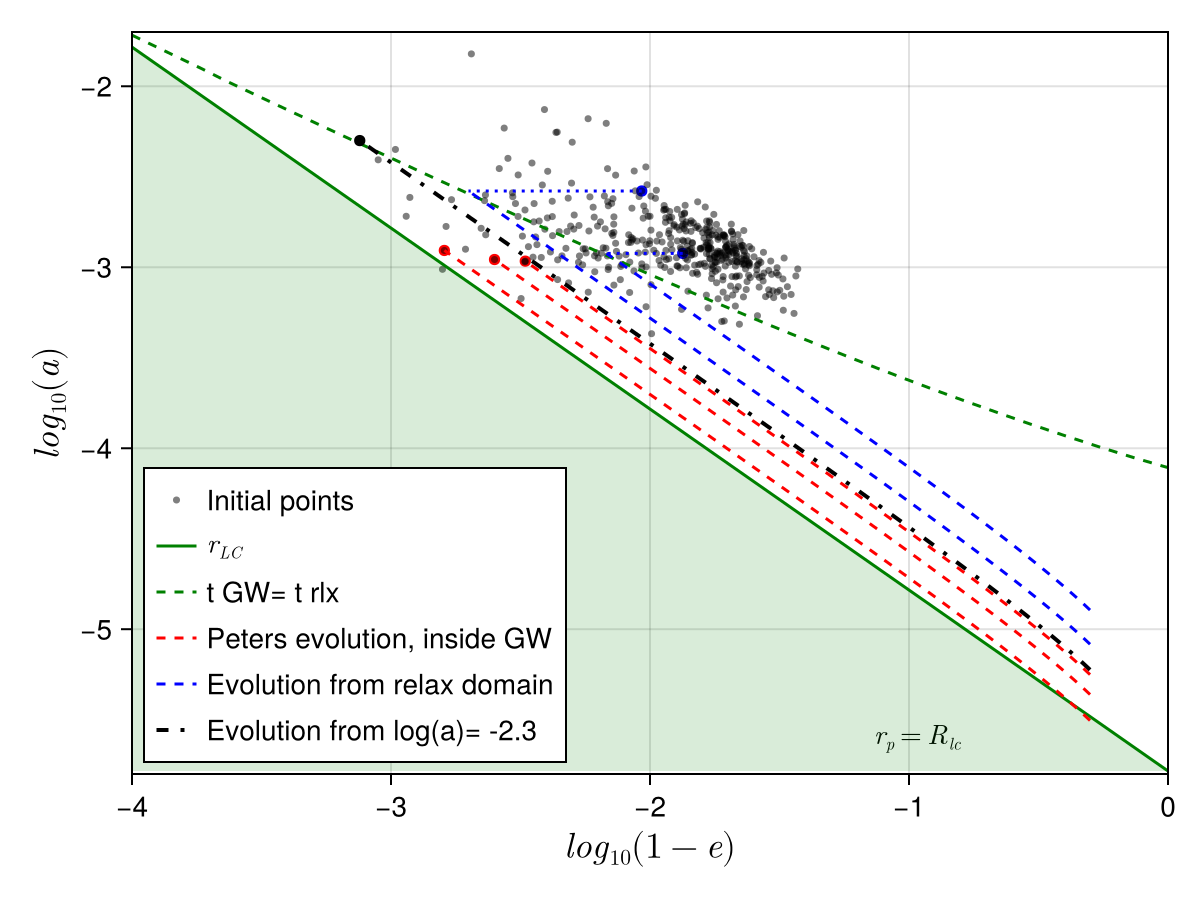

CairoMakie.Screen{PDF}


In [235]:
#mostramos estos puntos y su evolucion
function interseccion_horizontal(loga)
    f(x) = tgw_curve(x) - loga
    x_left, x_right = -4.0, 0.0
    for _ in 1:100
        x_mid = (x_left + x_right) / 2
        if f(x_mid) * f(x_left) < 0
            x_right = x_mid
        else
            x_left = x_mid
        end
    end
    return (x_left + x_right) / 2
end


fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)", xlabelsize = 18, ylabelsize= 18)
sc=CairoMakie.scatter!(ax, e_peter, a_peter, markersize = 8, color = :red)
sc2=CairoMakie.scatter!(ax, e_out, a_out, markersize = 8, color = :blue)
sc3=CairoMakie.scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color =(:black, 0.5) , markersize = 5, label="Initial points")
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(1 .-e), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(1 .-e)) - 0.8], [log10.(aux["rc"])[end] + 0.1], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
#Colorbar(fig[1, 2], sc3, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(-5.8,-1.7)

function a_peters(e, c0)
    return c0 * (e.^(12/19)) ./ (1 .- e.^2) .* (1 .+ 121/304 .* e.^2).^(870/2299)
end

first=true 

for (x_log1me, y_loga) in zip(e_peter, a_peter)
    e0 = 1 - 10^x_log1me
    a0 = 10^y_loga
    
    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0
    
    e_vals = range(0.5, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)

    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)
    
    if first
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5, label="Peters evolution, inside GW")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:red, linestyle=:dash, linewidth=1.5)
    end
end

first=true 

for (x_log1me, y_loga) in zip(e_out, a_out)
    x_inter = interseccion_horizontal(y_loga)

    lines!(ax, [x_log1me, x_inter], [y_loga, y_loga], color=:blue, linestyle=:dot, linewidth=1.5)

    e0 = 1 - 10^x_inter
    a0 = 10^y_loga

    f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
    c0 = a0 / f_e0

    e_vals = range(0.5, stop=e0, length=200)
    a_vals = a_peters(e_vals, c0)
    x_evol = log10.(1 .- e_vals)
    y_evol = log10.(a_vals)

    if first
        lines!(ax, x_evol, y_evol, color=:blue, linestyle=:dash, linewidth=1.5, label="Evolution from relax domain")
        first = false
    else
        lines!(ax, x_evol, y_evol, color=:blue, linestyle=:dash, linewidth=1.5)
    end
end

log_a0 = -2.3
a0=10^log_a0

log1me_0 = interseccion_horizontal(log_a0)

e0 = 1 - 10^log1me_0

f_e0 = (e0^(12/19)) / (1 - e0^2) * (1 + 121/304 * e0^2)^(870/2299)
c0 = a0 / f_e0

e_vals = range(0.5, stop=e0, length=200)
a_vals = a_peters(e_vals, c0)

x_evol = log10.(1 .- e_vals)
y_evol = log10.(a_vals)

lines!(ax, x_evol, y_evol, color=:black, linestyle=:dashdot, linewidth=2, label="Evolution from log(a)= -2.3")

CairoMakie.scatter!(ax, [log1me_0], [log_a0], color=:black, markersize=8)

leg=axislegend(ax, position = :lb)
display(fig)
save("Random evolutions.pdf", fig)

In [23]:
#check how deep can a binary goes, if 
r_lc = 8 * G *  (4.3e6 * Msun)  / c^2 * 3.24e-17
r_p = params["rlc"][2]/17
print(r_p)

1.6512100168731475e-6

In [24]:
r_lc #hasta beta 15 hace mas o menos sentido... the limit is beta equal 17 

1.6462756466012758e-6

In [245]:
# time to determinate some rates:
Rate_emris= length(sampled_e)/((t2-t1)*1e9) #in Gyr-1

8.84e-7

In [247]:
t_unique = sort(unique(EMRIs_time))
t_unique2 = sort(unique(EMRIs_time))
cm = countmap(EMRIs_time)
counts = [cm[t] for t in t_unique]
push!(t_unique2, t2) 
dt = diff(t_unique2)  

lambda_interval = counts ./ dt
lambda_interval_yr= lambda_interval/1e9

# Graficar como step (cada intervalo constante)
fig = Figure()
ax = Axis(fig[1,1],
    xlabel = L"\mathrm{t}\;[\,\mathrm{Gyr}\,]",
    ylabel = L"\mathrm{EMRIs}\;[\mathrm{yr}^{-1}]"
)
CairoMakie.lines!(ax, t_unique, lambda_interval_yr)
CairoMakie.scatter!(ax, t_unique, lambda_interval_yr, markersize=10)
save("Rates_per_time.pdf", fig)

CairoMakie.Screen{PDF}
